# Revision Experiments
In this file I will add the code for the multiple revision experiments

They fill follow the order:
1. Energy during inference in Gaussian and PC model
2. Variance and covariance capture in weights
3. Berkes all layers
4. visualise reconstruction for ambiguous input



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from moviepy.editor import VideoClip
from moviepy.video.io.bindings import mplfig_to_npimage
from torch.utils.data import  DataLoader
from torchvision.utils import save_image
import random, os

import predictive_coding as pc
from ResNet9 import ResNet9

from utils.training_evaluation import kl_divergence_discrete, MNIST_LinearClassifier
from utils.model import sample_x_fn_cte, sample_x_fn_normal, sample_x_fn, bernoulli_fn, bernoulli_fn_mask, fe_fn,fe_fn_mask, get_model, get_representations, random_step
from utils.training_evaluation import train, test, get_pc_trainer, get_mcpc_trainer, sample_pc
from utils.data import get_mnist_data
from utils.plotting import setup_fig, proba_to_coordinate

from matplotlib.ticker import StrMethodFormatter

random.seed(1)
np.random.seed(2)
torch.manual_seed(30)

pwd = os.getcwd()
path_models = pwd + "//models"

use_cuda = torch.cuda.is_available()
device = torch.device("cuda:0" if use_cuda else "cpu")

## Energy during inference in Gaussian and PC model
### Gaussian model

In [2]:
# network parameters
hidden_size = 1
output_size = 1

# sample a batch of data
batch_size = 256
data = torch.ones(batch_size, output_size)
pseudo_input = torch.zeros(batch_size, hidden_size)

# create model
gen_pc = nn.Sequential(
    nn.Linear(hidden_size,hidden_size), # input zeros ($pseudo_input) so that weight are disregarded and only biases are used
    pc.PCLayer(sample_x_fn=sample_x_fn),
    nn.Linear(hidden_size, output_size,bias=False),
)
# initialise model
gen_pc.train()
nn.init.constant_(gen_pc[0].bias, 0.2)
nn.init.constant_(gen_pc[2].weight, 2.)

config = {
    # variance of the sensory layer 
    "input_var":1.,
    "optimizer_x_fn_pc": optim.Adam,
    "optimizer_x_kwargs_pc":{"lr": 0.02},
    # parameters for MCPC inference
    "mixing":0,
    "sampling":300,
    "optimizer_x_kwargs_mcpc":{"lr": 0.02},
    "optimizer_p_fn_mcpc": optim.Adam,
    # sets sensory layer to Gaussian layer 
    "loss_fn": fe_fn 
}

# create MCPC trainer
mcpc_trainer = get_mcpc_trainer(gen_pc, config, training=False)

# MCPC inference
mc_results_gaus = mcpc_trainer.train_on_batch(
    inputs=pseudo_input,
    loss_fn=config["loss_fn"],
    loss_fn_kwargs={'_target': data, '_var':config["input_var"]},
    callback_after_t=random_step,
    callback_after_t_kwargs={'_pc_trainer':mcpc_trainer},
    is_sample_x_at_batch_start=True,
    is_return_results_every_t=True,
)

| l: 1.124e+02 | e: 3.328e+01 | o: 1.457e+02 |: 100%|██████████| 300/300 [00:01<00:00, 204.36it/s]


### MNIST model

In [3]:
config = {
    "batch_size_train":256,
    "batch_size_val": 256,
    "batch_size_test": 256,
    #
    "input_size": 20,
    "hidden_size": 128,
    "hidden2_size": 128,
    "output_size": 784,
    "loss_fn": bernoulli_fn ,
    "activation_fn": 'relu',
    "input_var":None,
    #
    "mixing":0,
    "sampling":300,
    "optimizer_x_kwargs_mcpc":{"lr": 0.1},
}


# Load MNIST data
train_loader, val_loader, test_loader = get_mnist_data(config)

# get model
model_pc = get_model(config, use_cuda)
model_name=path_models + "\mcpc_fid_1" 
gen_pc = get_model(config, use_cuda)
gen_pc.load_state_dict(torch.load(model_name),strict=False)
gen_pc.train()

# generate data
if config["loss_fn"]==fe_fn:
    loss_fn = fe_fn_mask
elif config["loss_fn"]==bernoulli_fn:
    loss_fn = bernoulli_fn_mask

# get trainers
mcpc_trainer = get_mcpc_trainer(gen_pc, config, training=False)


# data
pseudo_input = torch.zeros(config["batch_size_train"], config["input_size"])
data, _ = next(iter(train_loader))
data, pseudo_input = data.to(device), pseudo_input.to(device)

# MCPC inference
mc_results_mnist = mcpc_trainer.train_on_batch(
    inputs=pseudo_input,
    loss_fn=config["loss_fn"],
    loss_fn_kwargs={'_target': data, '_var':config["input_var"]},
    callback_after_t=random_step,
    callback_after_t_kwargs={'_pc_trainer':mcpc_trainer},
    is_sample_x_at_batch_start=True,
    is_return_results_every_t=True,
)


| l: 1.088e+04 | e: 4.052e+04 | o: 5.139e+04 |: 100%|██████████| 300/300 [00:04<00:00, 71.98it/s] 


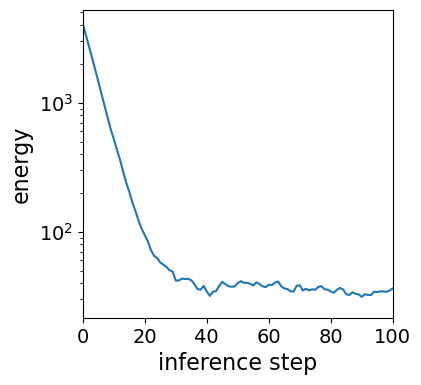

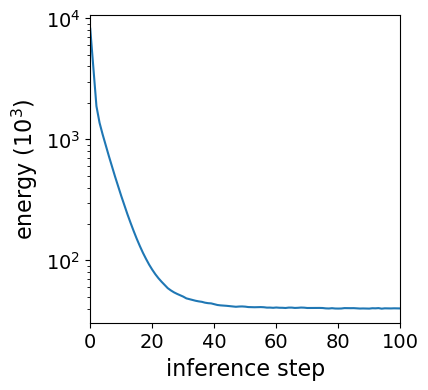

In [4]:
setup_fig(zero=False)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) 
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))  
plt.plot(mc_results_gaus["energy"])
plt.xlim(-0, 100)
plt.xlabel("inference step")
plt.ylabel("energy")
plt.yscale('log')

plt.figure()
setup_fig(zero=False)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) 
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))  
plt.plot([e/1000 for e in mc_results_mnist["energy"]])
plt.xlim(-0, 100)
plt.xlabel("inference step")
plt.ylabel("energy $(10^3)$")
plt.yscale('log')

## Variance and covariance capture in weights

### Gaussian model

In [5]:
# network parameters
hidden_size = 1
output_size = 1

# sample a batch of data
batch_size = 512
epochs = 3
n = 25
mu=1.
vars = np.linspace(2.0, 10, 9)


# create MCPC model    
gen_mcpc = nn.Sequential(
    nn.Linear(hidden_size,hidden_size), # input zeros so that weight are disregarded and only biases are used
    pc.PCLayer(sample_x_fn=sample_x_fn_normal),
    nn.Linear(hidden_size, output_size, bias=False),
)
gen_mcpc.train()
gen_mcpc.to(device)

config = {
    "hidden_size" : 1,
    "output_size" : 1,
    "input_size" : 1,
    "input_var":1.,
    "mixing":150,
    "sampling":1,
    "optimizer_x_kwargs_mcpc":{"lr": 0.01},
    "optimizer_p_fn_mcpc": optim.Adam,
    "optimizer_p_kwargs_mcpc": {"lr": 0.1},
    "loss_fn": fe_fn 
}

# create MCPC trainer
mcpc_trainer = get_mcpc_trainer(gen_mcpc, config, training=True)

params = np.zeros((len(vars),2))
dists = []
for var in vars:
    datas = [mu + np.sqrt(var)*torch.randn(batch_size, output_size).to(device) for i in range(n)]
    pseudo_input = torch.zeros(batch_size, hidden_size).to(device)

    nn.init.constant_(gen_mcpc[0].bias, np.random.randn()) # MCPC
    nn.init.constant_(gen_mcpc[2].weight, np.random.randn()) 

    for e in (range(epochs)):
        for idx, data in enumerate(tqdm(datas)):
            mcpc_trainer.train_on_batch(inputs=pseudo_input,loss_fn=config["loss_fn"],loss_fn_kwargs={'_target': data,'_var':config["input_var"]},callback_after_t=random_step,callback_after_t_kwargs={'_pc_trainer':mcpc_trainer},is_sample_x_at_batch_start=False, is_log_progress=False,is_checking_after_callback_after_t=False)
 
    params[vars==var,0] = gen_mcpc[0].bias.item()
    params[vars==var,1] = gen_mcpc[2].weight.item()

    # get data distribution
    dists += [sample_pc(10000, gen_mcpc, config, use_cuda=use_cuda)]

 16%|█▌        | 4/25 [00:01<00:11,  1.85it/s]

2.0
5.0
7.0
10.0


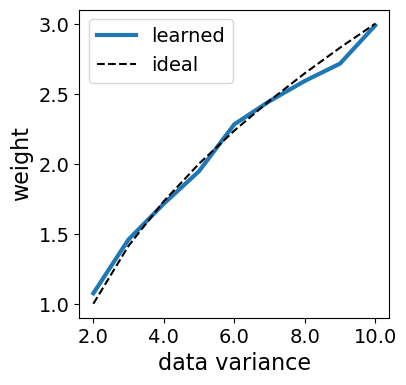

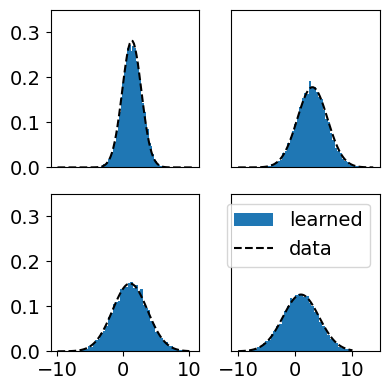

In [ ]:
setup_fig()
w_ideal = np.sqrt(vars-1)
plt.plot(vars, np.abs(params[:,1]), label="learned", linewidth=3)
plt.plot(vars, w_ideal, 'k--', label="ideal")
plt.xlabel("data variance")
plt.ylabel("weight")
plt.legend()
x = np.linspace(-10,10,100)


setup_fig()
plt.figure()
plt.subplot(2,2,1)
idx = 0
plt.hist(dists[idx].cpu().numpy(), bins=50, density=True)
plt.plot(x, np.exp(-(x-mu)**2/(2*vars[idx]))/np.sqrt(2*np.pi*vars[idx]), 'k--')
plt.ylim(0, 0.35)
plt.xticks([])
print(vars[idx])
plt.subplot(2,2,2)
idx = 3
plt.hist(dists[idx].cpu().numpy(), bins=50, density=True)
plt.plot(x, np.exp(-(x-mu)**2/(2*vars[idx]))/np.sqrt(2*np.pi*vars[idx]), 'k--')
plt.ylim(0, 0.35)
plt.xticks([])
plt.yticks([])
print(vars[idx])
plt.subplot(2,2,3)
idx = 5
plt.hist(dists[idx].cpu().numpy(), bins=50, density=True)
plt.plot(x, np.exp(-(x-mu)**2/(2*vars[idx]))/np.sqrt(2*np.pi*vars[idx]), 'k--')
plt.ylim(0, 0.35)
print(vars[idx])
plt.subplot(2,2,4)
idx = -1
plt.hist(dists[idx].cpu().numpy(), bins=50, density=True, label="learned")
plt.plot(x, np.exp(-(x-mu)**2/(2*vars[idx]))/np.sqrt(2*np.pi*vars[idx]), 'k--', label="data")
plt.ylim(0, 0.35)
plt.yticks([])
print(vars[idx])
plt.legend()
plt.tight_layout()

### Covariance of learned sensory neurons

Text(0, 0.5, 'sensory neuron index')

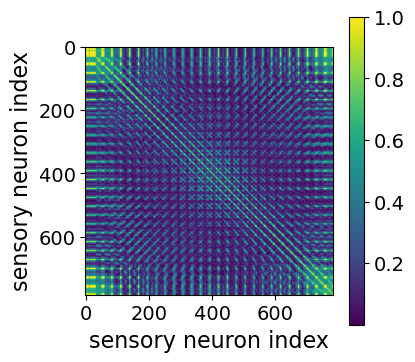

In [ ]:
config = {
    "batch_size_train":256,
    "batch_size_val": 256,
    "batch_size_test": 256,
    #
    "input_size": 20,
    "hidden_size": 128,
    "hidden2_size": 128,
    "output_size": 784,
    "loss_fn": bernoulli_fn ,
    "activation_fn": 'relu',
    "input_var":None,
    #
    "mixing":0,
    "sampling":300,
    "optimizer_x_kwargs_mcpc":{"lr": 0.03},
}


# Load MNIST data
train_loader, val_loader, test_loader = get_mnist_data(config)

# get model
model = get_model(config, use_cuda)
model_name=path_models + "\mcpc_fid_1" 
model = get_model(config, use_cuda)
model.load_state_dict(torch.load(model_name),strict=False)
model.train()

generative_samples =  sample_pc(10000, model, config, use_cuda=use_cuda, is_return_hidden=True).sigmoid()

from scipy.stats import spearmanr
cor = spearmanr(generative_samples.cpu().numpy())

# plot covariance matrix
setup_fig(zero=False)
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) 
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))  
plt.imshow(np.abs(cor[0]))
plt.colorbar()
plt.xlabel("sensory neuron index")
plt.ylabel("sensory neuron index")

## Berkes all layers

In [ ]:
# import copy
# from utils.data import GratingDataset, NoiseDataset
# from utils.model import zero_fn
# from utils.training_evaluation import KLdivergence

# epochs=[0, 5, 10, 15]

# config = {
#     #
#     "EPOCHS":50,
#     "batch_size_train":256,
#     "batch_size_val": 1024,
#     "batch_size_test": 256,
#     #
#     "input_size": 20,
#     "hidden_size": 128,
#     "hidden2_size": 128,
#     "output_size": 784,
#     "loss_fn": bernoulli_fn ,
#     "activation_fn": 'relu',
#     #
#     "T_pc":1000,
#     "optimizer_x_fn_pc": optim.Adam,
#     "optimizer_x_kwargs_pc":{"lr": 0.7},
#     #
#     "mixing":50,
#     "sampling":100,
#     "optimizer_x_kwargs_mcpc":{"lr": 0.1},
#     #
#     "optimizer_p_fn_mcpc": optim.Adam,
#     "optimizer_p_kwargs_mcpc": {"lr": 0.01, "weight_decay":0.},
#     "input_var":None
# }

# # Load MNIST data
# train_loader, val_loader, test_loader = get_mnist_data(config)
# # make gratings
# grating_dataset = GratingDataset(config["batch_size_test"], size=28, num_orientations=16)
# grating_loader = DataLoader(grating_dataset, batch_size=config["batch_size_test"], shuffle=True)
# # make noise
# noise_dataset = NoiseDataset(config["batch_size_test"], size=28)
# noise_loader = DataLoader(noise_dataset, batch_size=config["batch_size_test"], shuffle=True)

# # select 5 neurons randomly
# rand_idx = [random.sample(range(config["input_size"]), 5)]
# rand_idx += [random.sample(range(config["hidden_size"]), 5)]
# rand_idx += [random.sample(range(config["hidden2_size"]), 5)]

# kls_seed=[]
# seeds = range(10)
# for seed in seeds:
#     model_name_base= path_models + "\\epoch_save\\mcpc_aging_"+str(seed)+"_"

#     indent = 20 # indent to keep only part of data to prevent memory overload
#     kls = np.zeros((3, 3,len(epochs)))
#     for idx, epoch in enumerate(epochs):
#         # get model
#         gen_pc = get_model(config, use_cuda)
#         gen_pc.train()

#         # create trainers for genaration
#         config_gen = copy.deepcopy(config)
#         config_gen["mixing"] = 500
#         config_gen["sampling"] = 9500
#         config_gen["optimizer_x_kwargs_mcpc"] = {"lr": 0.1}

#         pc_trainer_gen = get_pc_trainer(gen_pc, config_gen, is_mcpc=True, training=False)
#         mcpc_trainer_gen = get_mcpc_trainer(gen_pc, config_gen, training=False)
        
#         model_name = model_name_base + "epoch"+str(epoch) if epoch!=0 else model_name_base + "epoch_init"
#         gen_pc.load_state_dict(torch.load(model_name), strict=False)

#         # load all data
#         data, _ = list(test_loader)[0]
#         grating_data = list(grating_loader)[0]
#         noise_data = list(noise_loader)[0]
#         pseudo_input = torch.zeros(data.shape[0], config_gen["input_size"])
#         if use_cuda:
#             pseudo_input, data, grating_data, noise_data = pseudo_input.cuda(), data.cuda(), grating_data.cuda(), noise_data.cuda()

#         # get spontaneous activity
#         pc_trainer_gen.train_on_batch(inputs=pseudo_input, loss_fn=zero_fn,loss_fn_kwargs={})
#         res_mcpc_prior = mcpc_trainer_gen.train_on_batch(inputs=pseudo_input,loss_fn=zero_fn, loss_fn_kwargs={},callback_after_t=random_step,
#                                     callback_after_t_kwargs={'_pc_trainer':mcpc_trainer_gen}, #
#                                     is_sample_x_at_batch_start=False, is_log_progress=True, is_return_results_every_t=True, is_return_xs=True)

#         ## get evoked activity
#         # for natural stimuli
#         pc_trainer_gen.train_on_batch(inputs=pseudo_input, loss_fn=config_gen["loss_fn"],loss_fn_kwargs={'_target': data},is_log_progress=False,is_return_results_every_t=False,is_checking_after_callback_after_t=False)
#         res_mcpc = mcpc_trainer_gen.train_on_batch(inputs=pseudo_input,loss_fn=config_gen["loss_fn"],loss_fn_kwargs={'_target': data}, 
#                                     callback_after_t=random_step, callback_after_t_kwargs={'_pc_trainer':mcpc_trainer_gen}, #
#                                     is_sample_x_at_batch_start=False, is_log_progress=True, is_return_results_every_t=True, is_return_xs=True)
#         # for gratings
#         pc_trainer_gen.train_on_batch(inputs=pseudo_input, loss_fn=config_gen["loss_fn"],loss_fn_kwargs={'_target': grating_data},is_log_progress=False,is_return_results_every_t=False,is_checking_after_callback_after_t=False)
#         res_mcpc_grating = mcpc_trainer_gen.train_on_batch(inputs=pseudo_input,loss_fn=config_gen["loss_fn"],loss_fn_kwargs={'_target': grating_data}, 
#                                     callback_after_t=random_step, callback_after_t_kwargs={'_pc_trainer':mcpc_trainer_gen}, #
#                                     is_sample_x_at_batch_start=False, is_log_progress=True, is_return_results_every_t=True, is_return_xs=True)
#         # for noise
#         pc_trainer_gen.train_on_batch(inputs=pseudo_input, loss_fn=config_gen["loss_fn"],loss_fn_kwargs={'_target': noise_data},is_log_progress=False,is_return_results_every_t=False,is_checking_after_callback_after_t=False)
#         res_mcpc_noise = mcpc_trainer_gen.train_on_batch(inputs=pseudo_input,loss_fn=config_gen["loss_fn"],loss_fn_kwargs={'_target': noise_data}, 
#                                     callback_after_t=random_step, callback_after_t_kwargs={'_pc_trainer':mcpc_trainer_gen}, #
#                                     is_sample_x_at_batch_start=False, is_log_progress=True, is_return_results_every_t=True, is_return_xs=True)

#         for latent in range(3):
#             prior = torch.concatenate([r[latent] for r in res_mcpc_prior["xs"][config_gen["mixing"]::]])
#             posterior_natural = torch.concatenate([r[latent] for r in res_mcpc["xs"][config_gen["mixing"]::]])
#             posterior_gratings = torch.concatenate([r[latent] for r in res_mcpc_grating["xs"][config_gen["mixing"]::]])
#             posterior_noise = torch.concatenate([r[latent] for r in res_mcpc_noise["xs"][config_gen["mixing"]::]])
            
#             ## data proprocessing
#             prior = prior[:,rand_idx[latent]]
#             posterior_natural = posterior_natural[:,rand_idx[latent]]
#             posterior_gratings = posterior_gratings[:, rand_idx[latent]]
#             posterior_noise = posterior_noise[:, rand_idx[latent]]

#             # compute KL divergence 
#             kls[latent, 0,idx] = KLdivergence(prior[::indent], posterior_natural[::indent])
#             kls[latent, 1,idx] = KLdivergence(prior[::indent], posterior_noise[::indent])
#             kls[latent, 2,idx] = KLdivergence(prior[::indent], posterior_gratings[::indent])

#         del prior, posterior_noise, posterior_gratings, posterior_natural
#     kls_seed.append(kls)

| l: 0.000e+00 | e: 2.670e+04 | o: 2.670e+04 |:  19%|█▉        | 191/1000 [00:01<00:05, 149.88it/s]


KeyboardInterrupt: 

In [ ]:
# kls_seed = np.array(kls_seed)

# for latent in range(3):
#     plt.figure()
#     # concatenate of data across seeds
#     kls_np = np.concatenate([k.reshape(k.shape[0],k.shape[1], 1) for k in kls_seed[:,latent,:,:]], axis=2)

#     # find mean and s.e.m.
#     kls_mean = kls_np.mean(-1)
#     kls_sem =  kls_np.std(-1)/kls_np.shape[-1]

#     # Set up the bar chart
#     conditions = [str(i) for i in epochs]
#     types = ['natural ', 'noise', 'gratings']
#     colors = ['C0', 'C1', 'C2']

#     fig, ax = plt.subplots()
#     bar_width = 0.2
#     index = np.arange(len(conditions))
#     for i, type_label in enumerate(types):
#         ax.bar(index + i * bar_width, kls_mean[i, :], bar_width, label=type_label, color=colors[i], yerr=[np.zeros_like(kls_sem[i, :])+0.05, kls_sem[i, :]], zorder=2, error_kw=dict(capsize = 4,zorder=1))

#     ax.set_ylim(0, None)
#     ax.set_ylabel('KL divergence')
#     ax.set_xlabel('Epochs')
#     ax.set_xticks(index + (bar_width * (len(types) - 1)) / 2)
#     ax.set_xticklabels(conditions)  


IndexError: too many indices for array: array is 1-dimensional, but 4 were indexed

<Figure size 400x400 with 0 Axes>

## Visualise reconstruction for ambiguous input

In [ ]:
img_kept = 0.5

config = {
    "batch_size_train":1024,
    "batch_size_val": 1024,
    "batch_size_test": 1024,
    #
    "input_size": 20,
    "hidden_size": 128,
    "hidden2_size": 128,
    "output_size": 784,
    "loss_fn": bernoulli_fn ,
    "activation_fn": 'relu',
    "input_var":None,
    #
    "T_pc":2000,
    "optimizer_x_fn_pc": optim.Adam,
    "optimizer_x_kwargs_pc":{"lr": 0.1},
    #
    "mixing":1000,
    "sampling":9000,
    "optimizer_x_kwargs_mcpc":{"lr": 0.03},
}


# Load MNIST data
train_loader, val_loader, test_loader = get_mnist_data(config)

# get model
gen_pc = get_model(config, use_cuda)
model_name=path_models + "\mcpc_ml_2" 
gen_pc = get_model(config, use_cuda)
gen_pc.load_state_dict(torch.load(model_name),strict=False)
gen_pc.train()

# generate data
if config["loss_fn"]==fe_fn:
    loss_fn = fe_fn_mask
elif config["loss_fn"]==bernoulli_fn:
    loss_fn = bernoulli_fn_mask

# get trainers
pc_trainer = get_pc_trainer(gen_pc, config, training=False, is_mcpc=True)
mcpc_trainer = get_mcpc_trainer(gen_pc, config, training=False)

################################################## get representations  ##########################################3
print("getting representations")
rep_dataset = get_representations(gen_pc, config, [pc_trainer, mcpc_trainer], val_loader, rep_type="MAP", use_cuda=use_cuda)
representations = DataLoader(rep_dataset, batch_size=512, shuffle=False)

################################################## train linear classifier ######################################3
# make classifier
classifier = MNIST_LinearClassifier(config["input_size"])
criterion = nn.CrossEntropyLoss()
optm = optim.Adam(classifier.parameters(), lr=0.05) #, momentum=0.0
if use_cuda:
    classifier.cuda()

# train classifier
print("training classifier")
EPOCHS = 10
for epoch_idx in range(EPOCHS):
    for data, label in representations:
        loss, _ = train(classifier, data, label, optm, criterion)
    test(classifier,representations,print_acc=True)

getting representations


| l: 6.718e+04 | e: 1.781e+04 | o: 8.499e+04 |: 100%|██████████| 2000/2000 [00:12<00:00, 163.74it/s]
| l: 6.818e+04 | e: 1.789e+04 | o: 8.607e+04 |: 100%|██████████| 2000/2000 [00:11<00:00, 179.24it/s]
| l: 6.879e+04 | e: 1.788e+04 | o: 8.667e+04 |: 100%|██████████| 2000/2000 [00:11<00:00, 177.42it/s]
| l: 6.717e+04 | e: 1.781e+04 | o: 8.499e+04 |: 100%|██████████| 2000/2000 [00:13<00:00, 152.82it/s]
| l: 6.688e+04 | e: 1.783e+04 | o: 8.471e+04 |: 100%|██████████| 2000/2000 [00:13<00:00, 144.05it/s]
| l: 6.755e+04 | e: 1.791e+04 | o: 8.546e+04 |: 100%|██████████| 2000/2000 [00:15<00:00, 125.23it/s]
| l: 6.653e+04 | e: 1.788e+04 | o: 8.440e+04 |: 100%|██████████| 2000/2000 [00:18<00:00, 109.42it/s]
| l: 6.692e+04 | e: 1.791e+04 | o: 8.483e+04 |: 100%|██████████| 2000/2000 [00:19<00:00, 103.90it/s]
| l: 6.623e+04 | e: 1.789e+04 | o: 8.412e+04 |: 100%|██████████| 2000/2000 [00:18<00:00, 106.15it/s]
| l: 6.774e+04 | e: 1.789e+04 | o: 8.563e+04 |: 100%|██████████| 2000/2000 [00:19<00:00, 10

KeyboardInterrupt: 

In [ ]:
################################################## make masked reconstruction ######################################3
digit = 4 # digit to analyse
data, label = list(test_loader)[1]
data, label = data[label==digit], label[label==digit]
pseudo_input = torch.zeros(data.shape[0],config["input_size"])
if use_cuda:
    pseudo_input, data, label = pseudo_input.cuda(), data.cuda(), label.cuda()

# perform inference with masked image
pc_results = pc_trainer.train_on_batch(inputs=pseudo_input, loss_fn=loss_fn,loss_fn_kwargs={'_target': data, '_var': config["input_var"], 'perc':img_kept}, is_log_progress=True, is_return_outputs=False, is_return_representations=True ,is_return_results_every_t=True, is_checking_after_callback_after_t=False)
mcpc_results = mcpc_trainer.train_on_batch(inputs=pseudo_input, loss_fn=loss_fn,loss_fn_kwargs={'_target': data, '_var': config["input_var"], 'perc':img_kept}, callback_after_t=random_step, callback_after_t_kwargs={'_pc_trainer':mcpc_trainer}, is_sample_x_at_batch_start=False, is_return_outputs=False, is_return_representations=True, is_log_progress=True, is_return_results_every_t=True, is_return_outputs=True)

# map representations to class probabilities using classifier
preds_pc = [torch.softmax(classifier(data.cuda() if use_cuda else data),1).detach().cpu() for data in pc_results["representations"]]
preds_mcpc = [torch.softmax(classifier(data.cuda() if use_cuda else data),1).detach().cpu() for data in mcpc_results["representations"]]
preds_mcpc = preds_mcpc[config['mixing']:]
# convert list of tensors to 3D tensor
preds_pc = torch.concatenate([p.view(-1,1,10) for p in preds_pc], axis=1)
preds_mcpc = torch.concatenate([p.view(-1,1,10) for p in preds_mcpc], axis=1)
